### Patch GAN trained directly on images

Python notebooks cannot be run due to unavailable data.

This project implements a conditional Generative Adversarial Network (GAN) for image compression artefact reduction using the Image-to-Image Translation with Conditional Adversarial Networks pix2pix framework. The model performs supervised image-to-image translation by learning a direct mapping between compressed input images and their corresponding clean targets.

#### Architecture
- Generator: U-Net encoder-decoder architecture with skip connections to preserve spatial information and fine image structure
- Discriminator: PatchGAN classifier operating on local image patches to encourage realistic high-frequency reconstruction
Training Objective

The generator is optimized using a weighted combination of:
- Adversarial loss — improves perceptual realism and texture quality
- L1 reconstruction loss — enforces structural similarity and reduces reconstruction error

The discriminator is trained to distinguish:
- real clean images & generated restored images

Training is performed on paired datasets consisting of JPEG-compressed artefact-corrupted images & corresponding uncompressed ground truth images

In [ ]:
import tensorflow as tf
import numpy as np
import os
import pathlib
import time
import datetime
import PIL
import PIL.Image
from matplotlib import pyplot as plt
from IPython import display
import glob
from math import log10, sqrt
from keras.utils.vis_utils import plot_model
from numpy.random import seed
import tensorflow_io as tfio
import keras

In [107]:
print(keras.__version__)

2.8.0


In [108]:
#to ensure reproducibility 
seed(1)
tf.random.set_seed(2)

In [109]:
#session.close()
#tensorflow allocate memory whenever it is needed
# gpu_options = tf.compat.v1.GPUOptions(per_process_gpu_memory_fraction=0.333)
# session = tf.compat.v1.InteractiveSession(config=tf.compat.v1.ConfigProto(gpu_options=gpu_options))

In [110]:
# The facade training set consist of 400 images
BUFFER_SIZE = 7420 #11230
BATCH_SIZE  = 1
img_height = 256
img_width = 256
OUTPUT_CHANNELS = 1

In [111]:
#Compressed images
real_dir = r'..\Data\20000_images_train\iaprtc12\images\01'
compressed_dir = r'..\Data\20000_images_train\iaprtc12\images\01\compressedImages'

In [113]:
def PSNR(original, compressed):
    mse = np.mean((original - compressed) ** 2)
    if(mse == 0):  # MSE is zero means no noise is present in the signal .
                  # Therefore PSNR have no importance.
        return 100
    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr

In [114]:
def load(image_file):
    image = tf.io.read_file(image_file)
    image = tf.io.decode_jpeg(image)
    image = resize(image) #changed to image
    ycbcr = tfio.experimental.color.rgb_to_ycbcr(image)
    input_image, cb, cr = ycbcr[:,:,0], ycbcr[:,:,1], ycbcr[:,:,2]
    input_image = tf.expand_dims(input_image, -1)
    input_image = tf.cast(input_image, tf.float32)
    return input_image

In [115]:
#resizing images
def resize(input_image):
    input_image = tf.image.resize(input_image, [img_height, img_width], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    #real_image = tf.image.resize(real_image, [img_height, img_width], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    return input_image#, real_image

In [116]:
# Normalizing the images to [-1, 1]
def normalize(input_image, real_image):
    input_image = (input_image / 127.5) - 1
    real_image = (real_image / 127.5) - 1
    return input_image, real_image

In [117]:
def load_image_train(input_image, real_image):
    input_image, real_image = normalize(input_image, real_image)
    return input_image, real_image

In [118]:
#TRAIN DATA
compressed_addresses = []
real_addresses = []
#quality_factor =  ['40', '45', '50', '55', '60', '70', '80']
quality_factor =  ['5','10', '15', '20', '25', '30', '35', '40', '50', '60', '70', '80']

for qf in quality_factor:
    compressed_addresses_q = glob.glob(compressed_dir+"/*q"+qf+".jpg")
    compressed_addresses_q.sort()
    compressed_addresses.extend(compressed_addresses_q)
    
    real_addresses_q = glob.glob(real_dir+"/*.jpg")
    real_addresses_q.sort()
    real_addresses.extend(real_addresses_q)

compressed_train_dataset = tf.data.Dataset.from_tensor_slices(compressed_addresses)
compressed_train_dataset = compressed_train_dataset.map(load)

real_train_dataset = tf.data.Dataset.from_tensor_slices(real_addresses)
real_train_dataset = real_train_dataset.map(load)

In [119]:
#combine to one dataset
train_dataset = tf.data.Dataset.zip((compressed_train_dataset, real_train_dataset))
train_dataset = train_dataset.map(load_image_train,
                                   num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(BUFFER_SIZE) 
train_dataset = train_dataset.batch(BATCH_SIZE) #sections it into Batch_size number of batches
train_dataset

<BatchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None))>

In [120]:
#VALIDATION DATA
#load them seperately
test_real_dir = r'..\Data\20000_images_train\iaprtc12\images\00'
test_compressed_dir = r'..\Data\20000_images_train\iaprtc12\images\00\compressedImages'

test_real_addresses = glob.glob(test_real_dir+"/*.jpg")
test_compressed_addresses = glob.glob(test_compressed_dir+"/*q5.jpg")

compressed_test_dataset = tf.data.Dataset.from_tensor_slices(test_compressed_addresses)
compressed_test_dataset = compressed_test_dataset.map(load)

real_test_dataset = tf.data.Dataset.from_tensor_slices(test_real_addresses)
real_test_dataset = real_test_dataset.map(load)

In [121]:
test_dataset = tf.data.Dataset.zip((compressed_test_dataset, real_test_dataset))
test_dataset = test_dataset.map(load_image_train,
                                   num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.shuffle(BUFFER_SIZE) 
test_dataset = test_dataset.batch(BATCH_SIZE)
test_dataset

<BatchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None))>

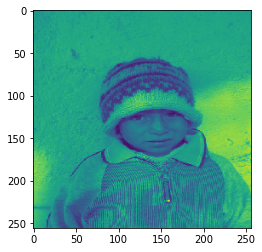

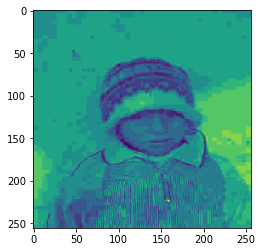

In [122]:
inp = load(str(r'..\Data\20000_images_train\iaprtc12\images\01\1000.jpg'))
re = load(str(r'..\Data\20000_images_train\iaprtc12\images\01\compressedImages\1000q5.jpg'))

# Casting to int for matplotlib to display the images

plt.figure()
plt.imshow(tf.squeeze(inp) / 255.0)
plt.figure()
plt.imshow(tf.squeeze(re) / 255.0)

In [123]:
def downsample(filters, size, apply_batchnorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)

    result = tf.keras.Sequential()
    result.add(
      tf.keras.layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))

    if apply_batchnorm:
        result.add(tf.keras.layers.BatchNormalization())

    result.add(tf.keras.layers.LeakyReLU())

    return result

In [124]:
down_model = downsample(3, 4)
down_result = down_model(tf.expand_dims(inp, 0))
print (down_result.shape)

(1, 128, 128, 3)


In [125]:
def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)

    result = tf.keras.Sequential()
    result.add(
        tf.keras.layers.Conv2DTranspose(filters, size, strides=2,
                                    padding='same',
                                    kernel_initializer=initializer,
                                    use_bias=False))

    result.add(tf.keras.layers.BatchNormalization())

    if apply_dropout:
        result.add(tf.keras.layers.Dropout(0.5))

    result.add(tf.keras.layers.ReLU())

    return result

In [126]:
up_model = upsample(3, 4)
up_result = up_model(down_result)
print (up_result.shape)

(1, 256, 256, 3)


In [127]:
def Generator():
    inputs = tf.keras.layers.Input(shape=[256, 256, 1])

    down_stack = [
        downsample(64, 4, apply_batchnorm=False),  # (batch_size, 128, 128, 64)
        #downsample(128, 4),  # (batch_size, 64, 64, 128)
        downsample(256, 4, apply_batchnorm=True),  # (batch_size, 32, 32, 256)
        #downsample(512, 4),  # (batch_size, 16, 16, 512)
        downsample(512, 4, apply_batchnorm=True),  # (batch_size, 8, 8, 512)
        #downsample(512, 4),  # (batch_size, 4, 4, 512)
        #downsample(512, 4),  # (batch_size, 2, 2, 512)
        downsample(512, 4, apply_batchnorm=True),  # (batch_size, 1, 1, 512)
    ]

    up_stack = [
        #upsample(512, 4, apply_dropout=True),  # (batch_size, 2, 2, 1024)
        #upsample(512, 4, apply_dropout=True),  # (batch_size, 4, 4, 1024)
        upsample(512, 4, apply_dropout=True),  # (batch_size, 8, 8, 1024)
        #upsample(512, 4),  # (batch_size, 16, 16, 1024)
        upsample(256, 4, apply_dropout=True),  # (batch_size, 32, 32, 512)
        #upsample(128, 4),  # (batch_size, 64, 64, 256)
        upsample(64, 4),  # (batch_size, 128, 128, 128)
    ]

    initializer = tf.random_normal_initializer(0., 0.02)
    last = tf.keras.layers.Conv2DTranspose(OUTPUT_CHANNELS, 4,
                                         strides=2,
                                         padding='same',
                                         kernel_initializer=initializer,
                                         activation='tanh')  # (batch_size, 256, 256, 3)

    x = inputs

    # Downsampling through the model
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)

    skips = reversed(skips[:-1])

    # Upsampling and establishing the skip connections
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = tf.keras.layers.Concatenate()([x, skip])

    x = last(x)

    return tf.keras.Model(inputs=inputs, outputs=x)

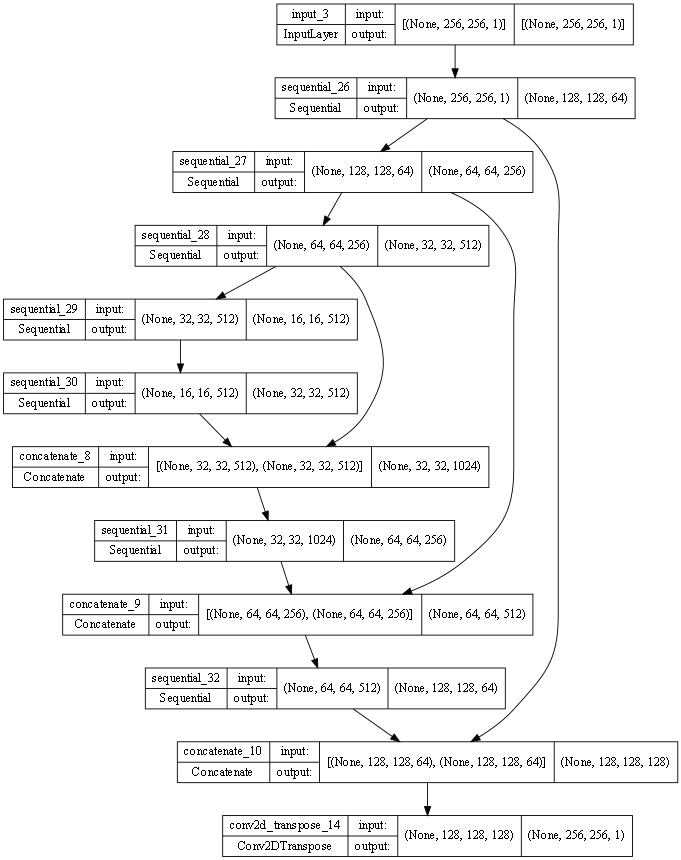

In [128]:
generator = Generator()
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64)

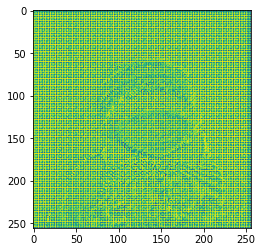

In [129]:
gen_output = generator(inp[tf.newaxis, ...], training=False)
plt.imshow(gen_output[0, ..., 0])

In [130]:
LAMBDA = 100
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [131]:
def generator_loss(disc_generated_output, gen_output, target):
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)

    # Mean absolute error
#     l1_loss = tf.reduce_mean(tf.abs(target - gen_output))
#total_gen_loss = gan_loss + (LAMBDA * l1_loss)

    l2_loss = tf.reduce_mean(tf.math.square(target - gen_output))

    total_gen_loss = gan_loss + (LAMBDA *l2_loss)
    

    return total_gen_loss, gan_loss, l2_loss

In [132]:
def Discriminator():
    initializer = tf.random_normal_initializer(0., 0.02)

    inp = tf.keras.layers.Input(shape=[256, 256, 1], name='input_image')
    tar = tf.keras.layers.Input(shape=[256, 256, 1], name='target_image')

    x = tf.keras.layers.concatenate([inp, tar])  # (batch_size, 256, 256, channels*2)

    down1 = downsample(64, 4, False)(x)  # (batch_size, 128, 128, 64)
    down2 = downsample(128, 4)(down1)  # (batch_size, 64, 64, 128)
    down3 = downsample(256, 4)(down2)  # (batch_size, 32, 32, 256)

    zero_pad1 = tf.keras.layers.ZeroPadding2D()(down3)  # (batch_size, 34, 34, 256)
    conv = tf.keras.layers.Conv2D(512, 4, strides=1,
                                kernel_initializer=initializer,
                                use_bias=False)(zero_pad1)  # (batch_size, 31, 31, 512)

    batchnorm1 = tf.keras.layers.BatchNormalization()(conv)

    leaky_relu = tf.keras.layers.LeakyReLU()(batchnorm1)

    zero_pad2 = tf.keras.layers.ZeroPadding2D()(leaky_relu)  # (batch_size, 33, 33, 512)

    last = tf.keras.layers.Conv2D(1, 4, strides=1,
                                kernel_initializer=initializer)(zero_pad2)  # (batch_size, 30, 30, 1)

    return tf.keras.Model(inputs=[inp, tar], outputs=last)

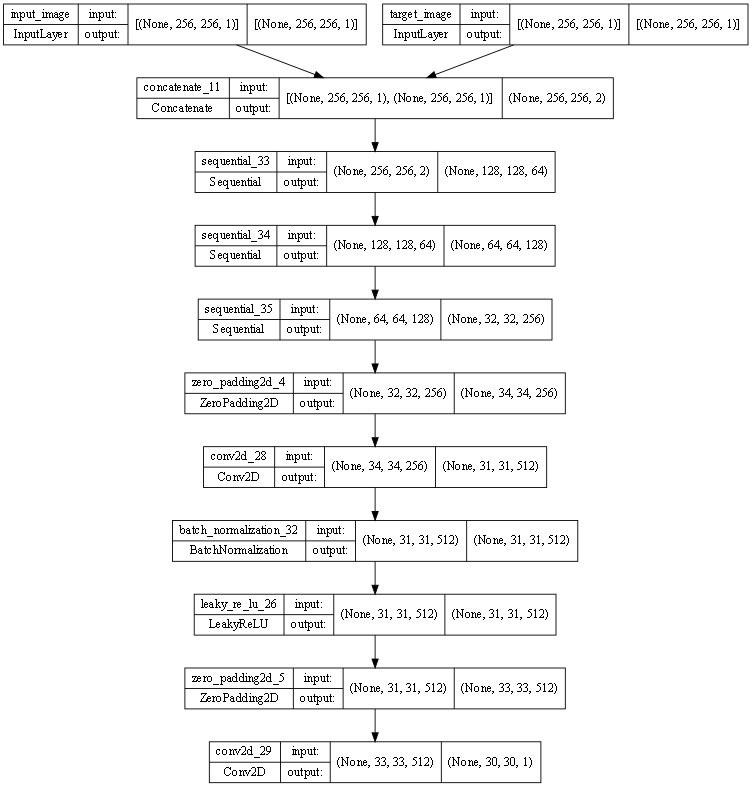

In [133]:
discriminator = Discriminator()
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64)

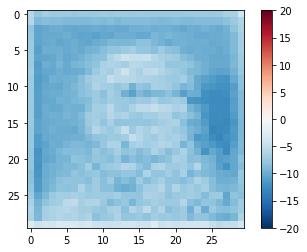

In [134]:
disc_out = discriminator([inp[tf.newaxis, ...], gen_output], training=False)
plt.imshow(disc_out[0, ..., 0], vmin=-20, vmax=20, cmap='RdBu_r')
plt.colorbar()

In [135]:
def disclossfunction(disc_real_output, disc_generated_output):
    generated_loss = -tf.math.log(disc_real_output) - tf.math.log(tf.ones_like(disc_generated_output)-disc_generated_output)
    return generated_loss

In [136]:
def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)

    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
    
    #generated_loss = disclossfunction(disc_real_output, disc_generated_output)

    total_disc_loss = real_loss + generated_loss
  

    return total_disc_loss

In [137]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5) #2e-4 lr
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)#2e-4 lr
# generator_optimizer =  tf.keras.optimizers.SGD(
#     learning_rate=0.01, momentum=0.0, nesterov=False, name='SGD', **kwargs
# )

In [138]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

In [139]:
def generate_images(model, test_input, tar):
    prediction = model(test_input, training=True)
    plt.figure(figsize=(15, 15))

    display_list = [test_input[0], tar[0], prediction[0]]
    title = ['Input Image', 'Ground Truth', 'Predicted Image']
    
    #PSNR
    PSNR_compressed = PSNR(test_input[0], tar[0])
    print(f"PSNR value is {PSNR_compressed} dB")
    PSNR_pred = PSNR(prediction[0], tar[0])
    print(f"PREDICTED PSNR value is {PSNR_pred} dB")
    
    #SSIM
    compressedssim = tf.image.ssim(test_input[0], tar[0], max_val=255, filter_size=11,
                          filter_sigma=1.5, k1=0.01, k2=0.03)
    print(f"SSIM value is {compressedssim} dB")
    pred_ssim = tf.image.ssim(prediction[0], tar[0], max_val=255, filter_size=11,
                          filter_sigma=1.5, k1=0.01, k2=0.03)
    print(f"PREDICTED SSIM value is {pred_ssim} dB")
    
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.title(title[i])
        # Getting the pixel values in the [0, 1] range to plot.
        plt.imshow(tf.squeeze(display_list[i]) * 0.5 + 0.5)
        plt.axis('off')
    plt.show()
#     tf.keras.utils.save_img('input_image.png', display_list[0])
#     tf.keras.utils.save_img('truth.png', display_list[1])
#     tf.keras.utils.save_img('prediction.png', display_list[2])

PSNR value is 71.10632714545255 dB
PREDICTED PSNR value is 54.83406930785392 dB
SSIM value is 0.9997862577438354 dB
PREDICTED SSIM value is 0.9735230207443237 dB


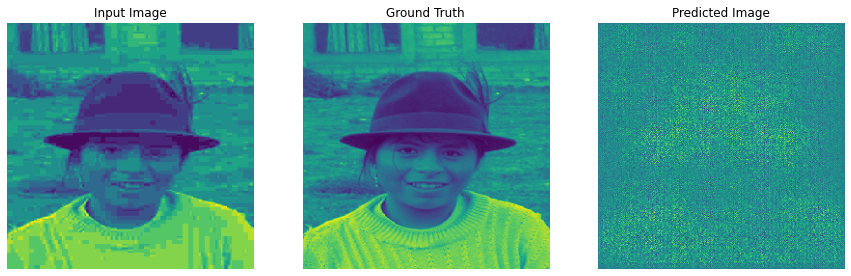

In [140]:
#before training
for example_input, example_target in test_dataset.take(1):
    generate_images(generator, example_input, example_target)

PSNR value is 69.7227655959323 dB
PREDICTED PSNR value is 51.13156781435351 dB
SSIM value is 0.999756395816803 dB
PREDICTED SSIM value is 0.9337693452835083 dB


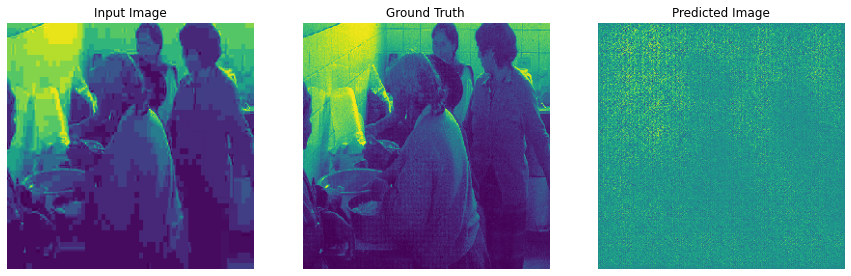

In [141]:
#before training
for example_input, example_target in test_dataset.take(1):
    generate_images(generator, example_input, example_target)

# Training

In [93]:
log_dir=r"Logs_GAN/"
summary_writer = tf.summary.create_file_writer(
    log_dir + "fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

In [94]:
@tf.function
def train_step(input_image, target, step):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_output = generator(input_image, training=True)
        
        disc_real_output = discriminator([input_image, target], training=True)
        disc_generated_output = discriminator([input_image, gen_output], training=True)
        
        gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(disc_generated_output, gen_output, target)
        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

    generator_gradients = gen_tape.gradient(gen_total_loss,
                                          generator.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss,
                                               discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(generator_gradients,
                                          generator.trainable_variables))
  
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                              discriminator.trainable_variables))
    
    with summary_writer.as_default():
        tf.summary.scalar('gen_total_loss', gen_total_loss, step=step//1000)
        tf.summary.scalar('gen_gan_loss', gen_gan_loss, step=step//1000)
        tf.summary.scalar('gen_l1_loss', gen_l1_loss, step=step//1000)
        tf.summary.scalar('disc_loss', tf.reduce_sum(disc_loss), step=step//1000)
    

In [95]:
def fit(train_ds, test_ds, steps):
    example_input, example_target = next(iter(test_ds.take(1)))
    start = time.time()

    for step, (input_image, target) in train_ds.repeat().take(steps).enumerate():
        if (step) % 1000 == 0:
            display.clear_output(wait=True)

        if step != 0:
            print(f'Time taken for 1000 steps: {time.time()-start:.2f} sec\n')

        start = time.time()

        #generate_images(generator, example_input, example_target)
        print(f"Step: {step//1000}k")

        train_step(input_image, target, step)
    
        # Training step
        if (step+1) % 10 == 0:
            print('.', end='', flush=True)


    # Save (checkpoint) the model every 5k steps
    if (step + 1) % 5000 == 0:
        checkpoint.save(file_prefix=checkpoint_prefix)
        

In [97]:
fit(train_dataset, test_dataset, steps=20000)

Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
.Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
.Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken 

Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
.Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
.Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken 

Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
.Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
.Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken 

Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
.Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
.Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken 

Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
.Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
.Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken 

.Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
.Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken for 1000 steps: 0.13 sec

Step: 19k
.Time taken for 1000 steps: 0.13 sec

Step: 19k
Time taken

In [98]:
#generator.save(r'..\Models\generator_YCbCr_XX', save_format='h5')

In [104]:
from tensorflow import keras
model = keras.models.load_model(r'..\Models\generator_YCbCr_PatchGan')

PSNR value is 68.95331890330793 dB
PREDICTED PSNR value is 69.52159152700814 dB
SSIM value is 0.9997156858444214 dB
PREDICTED SSIM value is 0.9997383952140808 dB


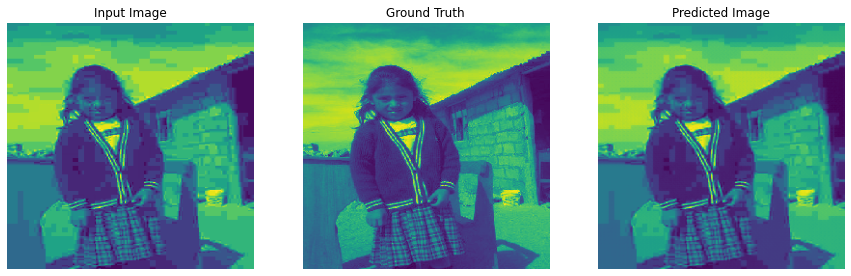

In [105]:
for example_input, example_target in test_dataset.take(1):
    generate_images(model, example_input, example_target)

In [43]:
#FINAL TEST BSD

In [53]:
BSDreal_dir = r'..\Data\CBSD68-dataset\CBSD68\original'
BSDcompressed_dir = r'..\Data\CBSD68-dataset\CBSD68\original\compressedImages'

BSDcompressed_addresses = []
BSDreal_addresses = []
BSDquality_factor =  ['40', '50', '60','70', '80']

for qf in BSDquality_factor:
    BSDcompressed_addresses_q = glob.glob(BSDcompressed_dir+"/*q"+qf+".jpg")
    BSDcompressed_addresses_q.sort()
    BSDcompressed_addresses.extend(BSDcompressed_addresses_q)
    
    BSDreal_addresses_q = glob.glob(BSDreal_dir+"/*.jpg")
    BSDreal_addresses_q.sort()
    BSDreal_addresses.extend(BSDreal_addresses_q)

BSDcompressed_dataset = tf.data.Dataset.from_tensor_slices(BSDcompressed_addresses)
BSDcompressed_dataset = BSDcompressed_dataset.map(load)

BSDreal_dataset = tf.data.Dataset.from_tensor_slices(BSDreal_addresses)
BSDreal_dataset = BSDreal_dataset.map(load)

In [54]:
#combine to one dataset
BSD_dataset = tf.data.Dataset.zip((BSDcompressed_dataset, BSDreal_dataset))
BSD_dataset = BSD_dataset.map(load_image_train,
                                   num_parallel_calls=tf.data.AUTOTUNE)
#BSD_dataset = BSD_dataset.shuffle(BUFFER_SIZE) 
BSD_dataset = BSD_dataset.batch(BATCH_SIZE) #sections it into Batch_size number of batches

In [55]:
def generate_images_BSD(model, test_input, tar, x):
    prediction = model(test_input, training=True)
    plt.figure(figsize=(15, 15))

    display_list = [test_input[0], tar[0], prediction[0]]
    title = ['Input Image', 'Ground Truth', 'Predicted Image']
    
    #PSNR
    PSNR_compressed = PSNR(test_input[0], tar[0])
    print(f"PSNR value is {PSNR_compressed} dB")
    PSNR_pred = PSNR(prediction[0], tar[0])
    print(f"PREDICTED PSNR value is {PSNR_pred} dB")
    
    #SSIM
    compressedssim = tf.image.ssim(test_input[0], tar[0], max_val=255, filter_size=11,
                          filter_sigma=1.5, k1=0.01, k2=0.03)
    print(f"SSIM value is {compressedssim} dB")
    pred_ssim = tf.image.ssim(prediction[0], tar[0], max_val=255, filter_size=11,
                          filter_sigma=1.5, k1=0.01, k2=0.03)
    print(f"PREDICTED SSIM value is {pred_ssim} dB")
    
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.title(title[i])
        # Getting the pixel values in the [0, 1] range to plot.
        plt.imshow(tf.squeeze(display_list[i]) * 0.5 + 0.5)
        plt.axis('off')
    plt.show()

In [ ]:
from PIL import Image
from IPython.display import display
x = 1
for example_input, example_target in BSD_dataset:
    generate_images_BSD(model, example_input, example_target, x)
    x = x + 1